# Errors and regularisation in pyTEM

One line of the Vechta tTEM survey (line 50 of the 5 m averaged Workbench export, 58 soundings) is inverted with every
regularisation pyTEM offers, with the same settings as InverTEM:

1. the data errors: STD, noise model and error floor
2. L2 smooth and L1 blocky (`invert_joint`), and how $\alpha$ is found
3. SCI fast and SCI adaptive (`invert_sci`), and what their parameters do
4. the vectorised inner kernel (`kernel='vectorized'`)

Everything is measured against the errors. With $m = \ln\rho$ per layer, the residual of gate $i$ is
$r_i = \ln(d_i / g_i(m)) / \sigma_i$, with $\sigma_i$ the relative STD used, and
$\mathrm{RMS} = \sqrt{\sum r_i^2 / N}$. RMS 1 means the data are fitted to within their errors, and every
regularisation below is made just strong enough to reach it.

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pytem").is_dir())
sys.path.insert(0, str(ROOT))
from pytem import (read_workbench_xyz, setup_shared_gate_matrices, cascade_filter, invert_joint, invert_stations,
                   invert_sci, noise_model, estimate_noise_level, fwd_circle_offset, getJ_ana)

## 1. Data and system

`read_workbench_xyz` reads the processed export with its `.gex`: waveforms, gate open/close times, loop, coil position,
Tx/Rx heights and low-pass filters. dB/dt is normalised by the current, in V/(A·m²).

In [2]:
tem = read_workbench_xyz("vechta_line50.xyz", "vechta_line50.gex")
MOMENTS = ["LM", "HM"]
E, N, _ = tem.utm_coords()
Z = tem.data["Elevation"].to_numpy()
distance = tem.distance_along_line()
print(f"{len(tem.data)} soundings over {distance[-1]:.0f} m, loop {tem.meta['LoopX']} x {tem.meta['LoopY']} m, "
      f"coil at {tem.meta['RXcoil_X_Position']} m, heights Tx {tem.meta['TxHeight']} m / Rx {tem.meta['RxHeight']} m, "
      f"low-pass {tem.meta['LowPass']} Hz")

58 soundings over 285 m, loop 2.9 x 2.9 m, coil at -9.28 m, heights Tx 0.97 m / Rx 0.3 m, low-pass (450000.0, 800000.0) Hz


In [3]:
ERROR_FLOOR, MAX_NOISE = 0.05, 0.50
thicknesses = np.diff(np.concatenate([[0.0], np.logspace(np.log10(2.0), np.log10(120.0), 14)]))   # 15 layers to 120 m
edges = np.concatenate([[0.0], np.cumsum(thicknesses), [thicknesses.sum() + 20.0]])                # half-space drawn 20 m thick
t_step, matrices = setup_shared_gate_matrices({m: tem.to_pytem(m, station=0) for m in MOMENTS}, n_step=75)

def fit_systems(station, floor=ERROR_FLOOR):
    "Gates of one sounding with a relative STD of at most MAX_NOISE; sigma = max(STD, floor)."
    systems = []
    for m in MOMENTS:
        kw = tem.to_pytem(m, station=station, min_noise=0.0)
        obs, std = kw["obs_data"], kw["noise_std"]
        good = np.isfinite(obs) & (obs > 0) & (std > 0) & (std <= MAX_NOISE)
        systems.append({"M": matrices[m][good], "obs": obs[good], "noise": np.maximum(std[good], floor) * obs[good],
                        "times": kw["times"][good]})
    return systems

system = dict(thicknesses=thicknesses, t_step=t_step, geometry="circle_offset",
              tx_size=np.sqrt(tem.meta["LoopX"] * tem.meta["LoopY"] / np.pi), rx_x=abs(tem.meta["RXcoil_X_Position"]),
              tx_height=tem.meta["TxHeight"], rx_height=tem.meta["RxHeight"],
              system_filter=cascade_filter(*tem.meta["LowPass"]), transform="euler")
joint = dict(system, rho_start=np.full(15, 100.0), maxit=50, step_backtrack=True, half_space_start=True, verbose=False)

## 2. The errors

**STD.** Each gate comes with a relative STD from the processing.

**Noise model.** $\mathrm{STD} = \sqrt{\mathrm{base}^2 + \left(\frac{N}{I}\,(t / 1\,\mathrm{ms})^{-1/2} / |d|\right)^2}$,
with $N$ the dB/dt noise at 1 ms in V/m² (one per moment) and base a uniform STD. `estimate_noise_level` takes $N$ from
the data's own STDs; `noise_model` returns the STDs.

**Error floor.** The inversion uses $\sigma = \max(\mathrm{STD}, \mathrm{floor})$, here 5 %, and leaves out gates above 50 %.

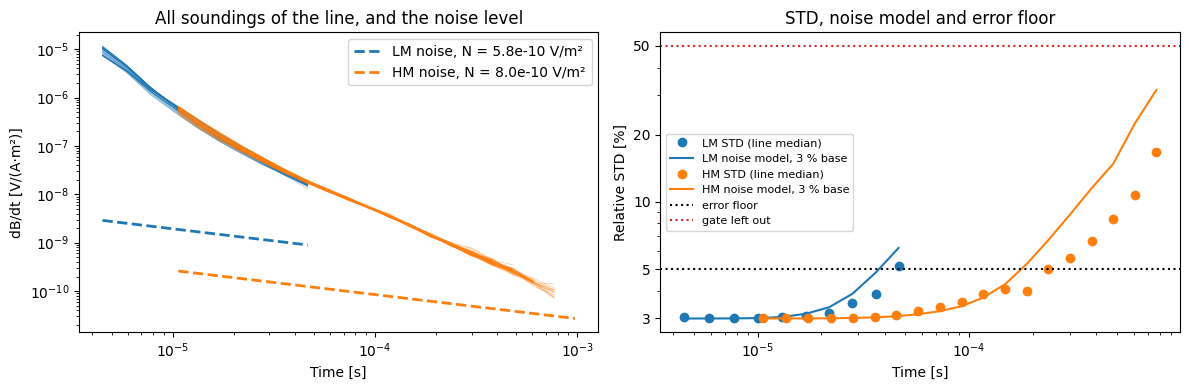

In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
for m, colour in zip(MOMENTS, ("C0", "C1")):
    t, d, std, current = tem.gate_times[m]["center"], tem.dbdt(m), tem.dbdt_std(m), tem.data[f"{m}current"].mean()
    level = estimate_noise_level(t, d, std, current)
    a.loglog(t, d.T, color=colour, lw=0.4, alpha=0.5)
    a.loglog(t, level / current * (t / 1e-3) ** -0.5, "--", color=colour, lw=2, label=f"{m} noise, N = {level:.1e} V/m²")
    median = lambda values: pd.DataFrame(values).median().to_numpy()   # per gate, ignoring missing data
    b.loglog(t, 100 * median(std), "o", color=colour, label=f"{m} STD (line median)")
    b.loglog(t, 100 * noise_model(t, median(d), current, level), color=colour, label=f"{m} noise model, 3 % base")
b.axhline(100 * ERROR_FLOOR, color="k", ls=":", label="error floor")
b.axhline(100 * MAX_NOISE, color="C3", ls=":", label="gate left out")
a.set(xlabel="Time [s]", ylabel="dB/dt [V/(A·m²)]", title="All soundings of the line, and the noise level")
b.set(xlabel="Time [s]", ylabel="Relative STD [%]", title="STD, noise model and error floor")
b.set_yticks([3, 5, 10, 20, 50], ["3", "5", "10", "20", "50"])
a.legend(); b.legend(fontsize=8)
plt.tight_layout()

The STDs of this export sit at 3 % (Workbench's uniform STD) until the noise takes over at late times, so with a 5 %
floor the early and middle gates are all weighted by the floor. The noise model is steeper than the late STDs of this
averaged export; the raw records of the survey follow it closely.

The floor is part of the regularisation: the larger it is, the smoother the model that reaches RMS 1. A floor that is too
small asks for structure the data cannot support.

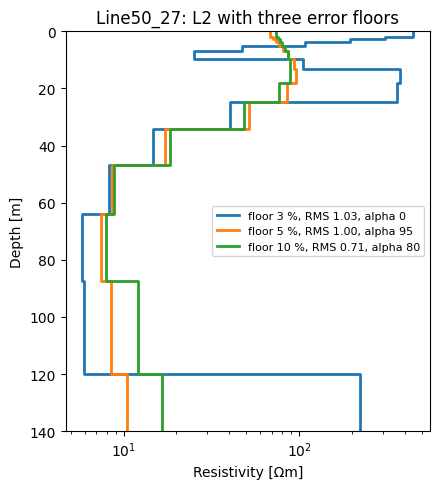

In [5]:
station = 26
stairs = lambda ax, rho, **style: ax.plot(np.repeat(rho, 2), np.repeat(edges, 2)[1:-1], **style)

fig, ax = plt.subplots(figsize=(4.5, 5))
for floor in (0.03, 0.05, 0.10):
    result = invert_joint(fit_systems(station, floor), adaptive_alpha=True, **joint)
    stairs(ax, result["resistivities"], lw=2, label=f"floor {100 * floor:.0f} %, RMS {result['rms']:.2f}, alpha {result['alpha_final']:.0f}")
ax.set(xscale="log", xlabel="Resistivity [Ωm]", ylabel="Depth [m]", ylim=(edges[-1], 0),
       title=f"{tem.data['SoundingName'][station]}: L2 with three error floors")
ax.legend(fontsize=8)
plt.tight_layout()

## 3. L2 smooth and L1 blocky

Both minimise $\sum r_i^2 + \alpha \sum_k w_k\,\Delta_k^2 / \Delta z_k$, with $\Delta_k$ the step in $\ln\rho$ between
adjacent layers and $\Delta z_k$ the distance between layer centres.

- **L2** (`norm='l2'`): $w_k = 1$. One large step costs far more than several small ones, so contrasts are spread over
  many layers.
- **L1** (`norm='l1'`): $w_k = 1 / \sqrt{\Delta_k^2 + 0.05^2}$ from the current model, every iteration (IRLS). The cost
  of a step is then about $|\Delta_k|$: a large step costs the same as small ones adding up to it, so layers stay flat
  and boundaries sharp.

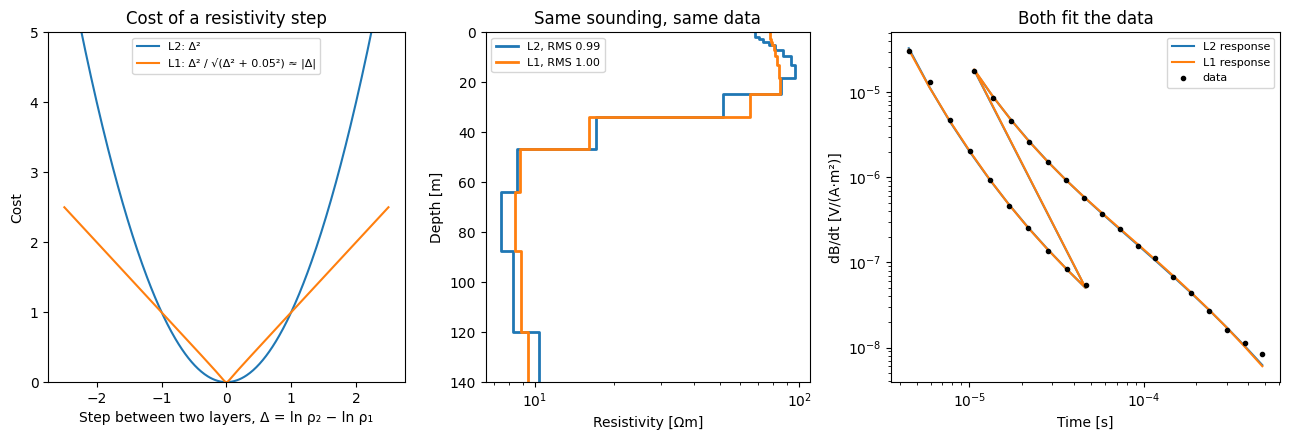

In [6]:
results = {norm: invert_joint(fit_systems(station), norm=norm, **joint) for norm in ("l2", "l1")}
times = np.concatenate([f["times"] for f in fit_systems(station)])

fig, (a, b, c) = plt.subplots(1, 3, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.1, 1, 1.2]})
step = np.linspace(-2.5, 2.5, 401)
a.plot(step, step ** 2, label="L2: Δ²")
a.plot(step, step ** 2 / np.sqrt(step ** 2 + 0.05 ** 2), label="L1: Δ² / √(Δ² + 0.05²) ≈ |Δ|")
a.set(xlabel="Step between two layers, Δ = ln ρ₂ − ln ρ₁", ylabel="Cost", ylim=(0, 5), title="Cost of a resistivity step")
for norm, result in results.items():
    stairs(b, result["resistivities"], lw=2, label=f"{norm.upper()}, RMS {result['rms']:.2f}")
    c.loglog(times, result["predicted"], "-", label=f"{norm.upper()} response")
c.loglog(times, results["l2"]["observed"], "k.", label="data")
b.set(xscale="log", xlabel="Resistivity [Ωm]", ylabel="Depth [m]", ylim=(edges[-1], 0), title="Same sounding, same data")
c.set(xlabel="Time [s]", ylabel="dB/dt [V/(A·m²)]", title="Both fit the data")
for ax in (a, b, c):
    ax.legend(fontsize=8)
plt.tight_layout()

### How $\alpha$ is found

1. Start from the best of 33 half-spaces (`half_space_start=True`); the first $\alpha$ is the largest term of the misfit gradient.
2. Each iteration tries up to 5 values, $\alpha \times 0.77$ each ($10^{-1/9}$); a trial halves its step until the RMS improves.
3. The ladder stops at the first trial below RMS 1. Kept: the largest $\alpha$ with RMS ≤ 1, otherwise the lowest RMS.
4. The next iteration starts one rung higher. It ends at RMS ≤ 1, when it stalls or stagnates, or after `maxit` iterations.

With `adaptive_alpha=True`, a trial that undershoots (RMS below 0.995) is followed by one more at the $\alpha$
interpolated to RMS 1, so the smoothest model that fits is kept.

In [7]:
for adaptive in (False, True):
    print(f"adaptive_alpha={adaptive}")
    result = invert_joint(fit_systems(station), **{**joint, "verbose": True, "adaptive_alpha": adaptive})
    print(f"  -> RMS {result['rms']:.3f} after {result['n_iter']} iterations, alpha {result['alpha_final']:.1f}\n")

adaptive_alpha=False
    Alpha = 542.63,  RMS = 2.25
    Alpha = 420.14,  RMS = 2.13
    Alpha = 325.30,  RMS = 2.03
    Alpha = 251.87,  RMS = 1.95
    Alpha = 195.01,  RMS = 1.89
    Alpha = 251.87,  RMS = 1.21
    Alpha = 195.01,  RMS = 1.15
    Alpha = 150.99,  RMS = 1.10
    Alpha = 116.91,  RMS = 1.06
    Alpha = 90.52,  RMS = 1.04
    Alpha = 116.91,  RMS = 1.03
    Alpha = 90.52,  RMS = 0.99
    RMS below 1 - stopping ladder.
  -> RMS 0.994 after 3 iterations, alpha 90.5

adaptive_alpha=True
    Alpha = 542.63,  RMS = 2.25
    Alpha = 420.14,  RMS = 2.13
    Alpha = 325.30,  RMS = 2.03
    Alpha = 251.87,  RMS = 1.95
    Alpha = 195.01,  RMS = 1.89
    Alpha = 251.87,  RMS = 1.21
    Alpha = 195.01,  RMS = 1.15
    Alpha = 150.99,  RMS = 1.10
    Alpha = 116.91,  RMS = 1.06
    Alpha = 90.52,  RMS = 1.04
    Alpha = 116.91,  RMS = 1.03
    Alpha = 90.52,  RMS = 0.99
    RMS below 1 - stopping ladder.
    Alpha = 94.78,  RMS = 1.00
  -> RMS 0.999 after 3 iterations, alpha 94.8



### The whole line, one sounding at a time

`invert_stations` inverts every sounding on its own: nothing ties neighbours together.

In [21]:
def invert_line(**options):
    t0 = time.perf_counter()
    results = invert_stations(range(len(tem.data)), lambda s: {"fit_systems": fit_systems(s)},
                              invert_kwargs={**joint, "adaptive_alpha": True, **options}, max_workers=4)
    rho, rms = (np.array([results[s][key] for s in results]) for key in ("resistivities", "rms"))
    print(f"{options}: median RMS {np.median(rms):.2f}, {time.perf_counter() - t0:.0f} s")
    return rho, rms

def section(ax, rho, title, cmap="viridis"):
    x = np.concatenate([[distance[0] - 2.5], (distance[1:] + distance[:-1]) / 2, [distance[-1] + 2.5]])
    for k in range(len(rho)):
        mesh = ax.pcolormesh(x[k:k + 2], Z[k] - edges, rho[k][:, None], norm=LogNorm(3, 150), cmap=cmap)
    ax.set(title=title, ylabel="Elevation [m]")
    return mesh

rho_l2, rms_l2 = invert_line(norm="l2")
rho_l1, rms_l1 = invert_line(norm="l1")

{'norm': 'l2'}: median RMS 1.00, 44 s
{'norm': 'l1'}: median RMS 1.00, 40 s


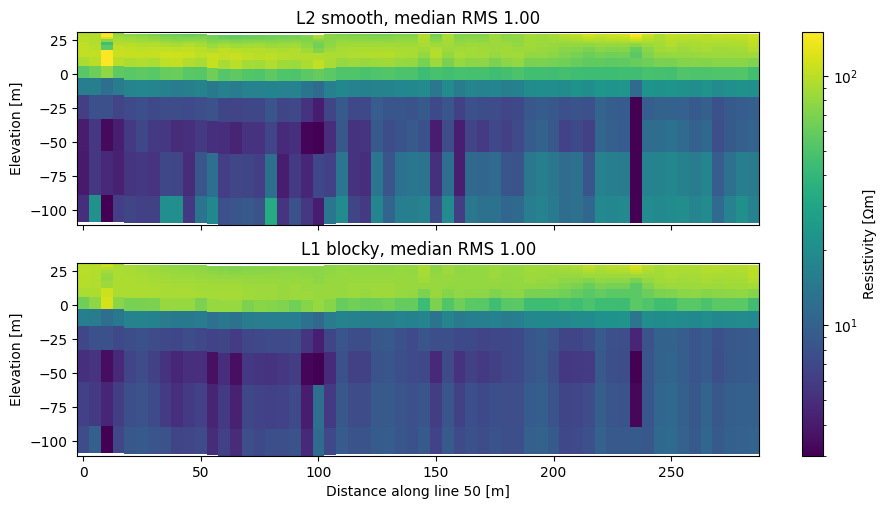

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for ax, rho, rms, name in zip(axes, (rho_l2, rho_l1), (rms_l2, rms_l1), ("L2 smooth", "L1 blocky")):
    mesh = section(ax, rho, f"{name}, median RMS {np.median(rms):.2f}")
axes[1].set_xlabel("Distance along line 50 [m]")
fig.colorbar(mesh, ax=axes, label="Resistivity [Ωm]")
plt.show()

## 4. SCI fast

All soundings are inverted in one system. Each constraint says "the difference in $\ln\rho$ is $0 \pm \sigma$", with
$\sigma = \ln(\mathrm{factor})$, and adds $(\Delta\ln\rho / \sigma)^2$ to the objective, exactly as a gate adds its
squared misfit over its STD:

| Parameter | Default | What it sets |
|---|---|---|
| `vertical_factor` | 3 | resistivity ratio between adjacent layers that costs 1 STD |
| `lateral_factor` | 1.5 | ratio between map neighbours that costs 1 STD, at the reference distance |
| `reference_distance` | 100 m | distance at which the lateral factor applies |
| `distance_power` | 0.5 | exponent $p$: $\sigma(d) = \ln(\mathrm{lateral\ factor}) \cdot (d / d_\mathrm{ref})^p$ |
| `elevation_constraints` | True | compare neighbours at the same elevation, or at the same depth |
| `maxit` | 30 | iteration limit |

For `vertical_factor=3`, the penalty between adjacent layers $i$ and $i+1$ is

$$
\left[\frac{\ln(\rho_{i+1}/\rho_i)}{\ln(3)}\right]^2.
$$

Thus equal resistivities cost 0, a change from 30 to 90 $\Omega\mathrm{m}$ (or 90 to 30) costs 1, and a change from 30 to 270 $\Omega\mathrm{m}$ costs 4. The factor is a soft constraint, not a maximum allowed ratio: the inversion may choose a larger contrast when the data require it.

Neighbours are the Delaunay edges of the sounding positions. The strength is fixed by the factors: there is no $\alpha$.
Marquardt damping is raised until the step is within a step limit and the median RMS falls, and the run stops once the
median RMS reaches 1, before the soundings that already fit are over-fitted.

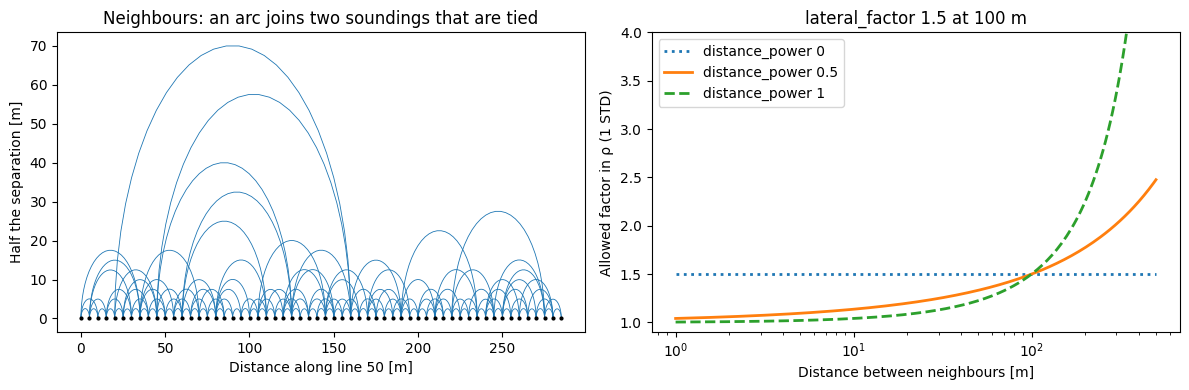

In [10]:
from pytem.inversion import _neighbour_edges

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
arc = np.linspace(0, np.pi, 30)
for i, j in _neighbour_edges(E, N):   # an arc joins two soundings that are tied
    a.plot(distance[[i, j]].mean() + abs(distance[i] - distance[j]) / 2 * np.cos(arc), abs(distance[i] - distance[j]) / 2 * np.sin(arc), color="C0", lw=0.6)
a.plot(distance, 0 * distance, "k.", ms=4)
a.set(xlabel="Distance along line 50 [m]", ylabel="Half the separation [m]", title="Neighbours: an arc joins two soundings that are tied")
d = np.logspace(0, np.log10(500), 200)
for power, style in ((0.0, ":"), (0.5, "-"), (1.0, "--")):
    b.semilogx(d, np.exp(np.log(1.5) * (d / 100) ** power), style, lw=2, label=f"distance_power {power:g}")
b.set(xlabel="Distance between neighbours [m]", ylabel="Allowed factor in ρ (1 STD)", ylim=(0.9, 4),
      title="lateral_factor 1.5 at 100 m")
b.legend()
plt.tight_layout()

In [11]:
stations = [fit_systems(s) for s in range(len(tem.data))]
sci = dict(system, x=E, y=N, elevation=Z)

t0 = time.perf_counter()
fast = invert_sci(stations, **sci)
print(f"{fast['termination_reason']}: median RMS {np.median(fast['rms']):.2f}, {time.perf_counter() - t0:.0f} s")

SCI: vertical factor 3, lateral factor 1.5
  iteration 1: median RMS 2.60, 58 of 58 soundings active
  iteration 2: median RMS 1.05, 58 of 58 soundings active
  iteration 3: median RMS 0.86, 58 of 58 soundings active
median_rms_below_1: median RMS 0.86, 29 s


### The distance power

Soundings are 5 m apart here, far below the 100 m reference distance, so the power decides how tightly neighbours are tied:
with $p = 0$ a factor 1.5 is allowed between them, with $p = 0.5$ about 1.09 and with $p = 1$ only 1.02.

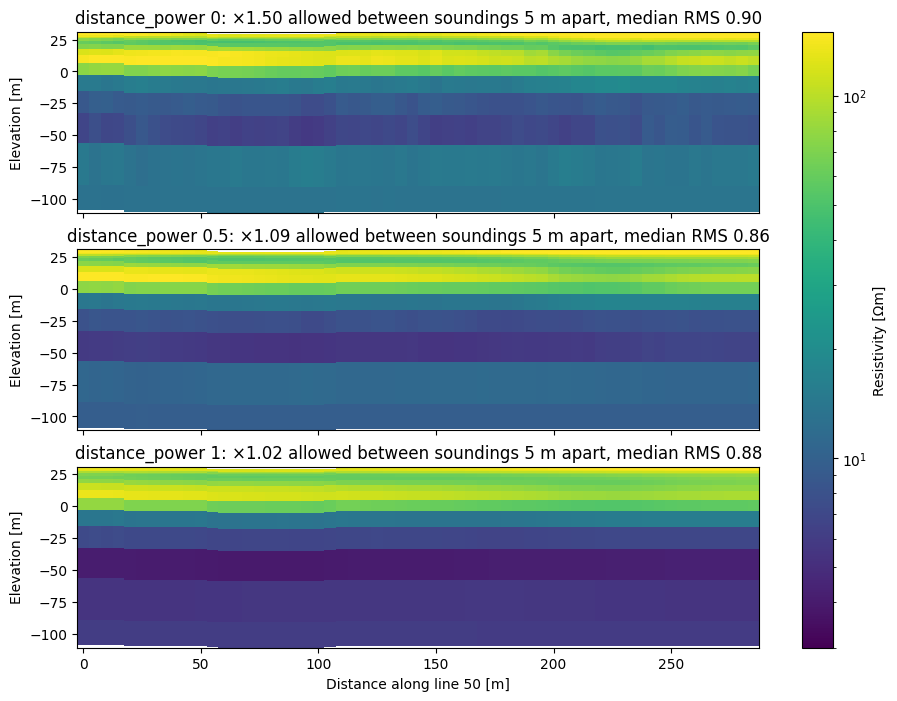

In [ ]:
powers = {0.5: fast, **{p: invert_sci(stations, 
                                      distance_power=p, 
                                      verbose=False, **sci) 
                                      for p in (0.0, 1.0, 2.0)}}

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, p in zip(axes, sorted(powers)):
    r = powers[p]
    mesh = section(ax, r["resistivities"], f"distance_power {p:g}: ×{1.5 ** (0.05 ** p):.2f} allowed between soundings 5 m apart, "
                   f"median RMS {np.median(r['rms']):.2f}", cmap="turbo")
axes[-1].set_xlabel("Distance along line 50 [m]")
fig.colorbar(mesh, ax=axes, label="Resistivity [Ωm]")
plt.show()

### Vertical and lateral factor comparison

The two factors control different directions, so they are varied one at a time. The vertical sweep keeps `lateral_factor=1.5`; the lateral sweep keeps `vertical_factor=3`.

**A higher factor means weaker regularisation and therefore less smoothing.** A factor closer to 1 penalises small resistivity differences more strongly and produces a smoother model. Thus, increasing `vertical_factor` permits sharper changes between layers, while increasing `lateral_factor` permits larger differences between neighbouring soundings.

For example, a factor-3 resistivity contrast has penalty 1 when `vertical_factor=3`, but only $(\ln 3 / \ln 6)^2 \approx 0.38$ when `vertical_factor=6`.

In [ ]:
vertical_factors = (1.5, 3.0, 6.0, 12.0)
lateral_factors = (1.1, 1.5, 2.0, 3.0)

vertical_runs = {
    factor: fast if factor == 3.0 else invert_sci(
        stations, vertical_factor=factor, lateral_factor=1.5, verbose=False, **sci
    )
    for factor in vertical_factors
}
lateral_runs = {
    factor: fast if factor == 1.5 else invert_sci(
        stations, vertical_factor=3.0, lateral_factor=factor, verbose=False, **sci
    )
    for factor in lateral_factors
}

fig, axes = plt.subplots(2, len(vertical_factors), figsize=(13, 5), sharex=True, sharey=True)
for row, (name, runs) in enumerate((("vertical", vertical_runs), ("lateral", lateral_runs))):
    for ax, (factor, result) in zip(axes[row], runs.items()):
        mesh = section(
            ax, result["resistivities"],
            f"{name} factor = {factor:g}\nmedian RMS = {np.median(result['rms']):.2f}",
            cmap="turbo",
        )
axes[-1, 1].set_xlabel("Distance along line 50 [m]")
fig.colorbar(mesh, ax=axes, label="Resistivity [Ωm]")
plt.tight_layout()
plt.show()

factor_comparison = pd.DataFrame(
    [
        {"varied_factor": name, "factor": factor,
         "median_rms": np.median(result["rms"]),
         "maximum_rms": np.max(result["rms"]),
         "iterations": result["n_iter"]}
        for name, runs in (("vertical", vertical_runs), ("lateral", lateral_runs))
        for factor, result in runs.items()
    ]
).round(3)
factor_comparison

C:\Users\pamcl\AppData\Local\Temp\ipykernel_6776\2358063108.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


## 5. SCI adaptive

SCI fast uses the strength it is given. SCI adaptive (`adaptive=True`) looks for the tightest constraints that still fit:
both factors are raised to the powers 0.25, 0.35, 0.5, 0.7, 1, 1.4, 2, 2.8 and 4, from tight to loose. Each run starts
from the previous models and runs to convergence, and the first run with a total RMS ≤ 1 is kept (total, so that
soundings that fit poorly count).

In [13]:
t0 = time.perf_counter()
adaptive = invert_sci(stations, adaptive=True, **sci)
print(f"{time.perf_counter() - t0:.0f} s")
pd.DataFrame(adaptive["runs"]).round(3)

SCI: vertical factor 1.32, lateral factor 1.11
  iteration 1: median RMS 1.95, 58 of 58 soundings active
  iteration 2: median RMS 1.09, 58 of 58 soundings active
  iteration 3: median RMS 1.08, 58 of 58 soundings active
  iteration 4: median RMS 1.08, 58 of 58 soundings active
SCI: vertical factor 1.47, lateral factor 1.15
  iteration 1: median RMS 0.95, 58 of 58 soundings active
  iteration 2: median RMS 0.95, 58 of 58 soundings active
92 s


,vertical_factor,lateral_factor,total_rms,median_rms,n_iter,termination_reason
0,1.316,1.107,1.092,1.078,4,minimum_step
1,1.469,1.152,0.971,0.939,2,minimum_step


## 6. Same data, four regularisations

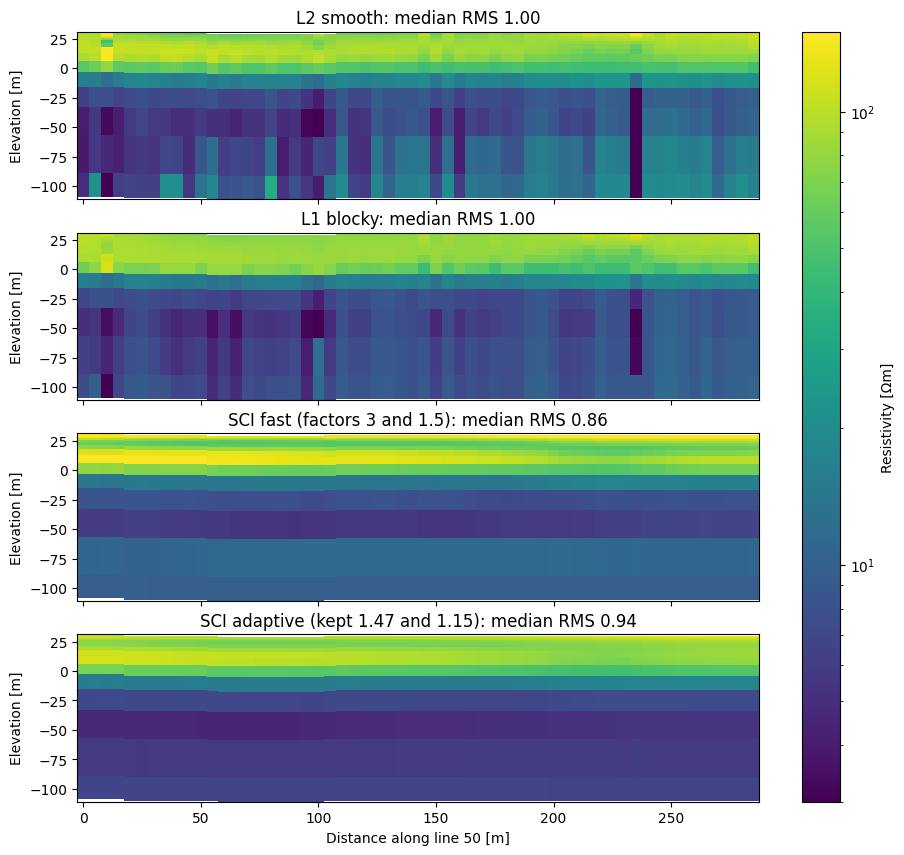

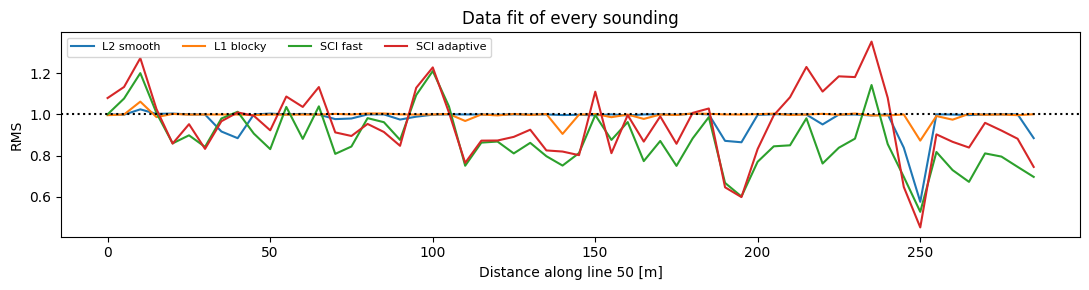

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
panels = (("L2 smooth", rho_l2, rms_l2), ("L1 blocky", rho_l1, rms_l1),
          (f"SCI fast (factors {fast['vertical_factor']:g} and {fast['lateral_factor']:g})", fast["resistivities"], fast["rms"]),
          (f"SCI adaptive (kept {adaptive['vertical_factor']:.2f} and {adaptive['lateral_factor']:.2f})", adaptive["resistivities"], adaptive["rms"]))
for ax, (name, rho, rms) in zip(axes, panels):
    mesh = section(ax, rho, f"{name}: median RMS {np.median(rms):.2f}", cmap="turbo")
axes[-1].set_xlabel("Distance along line 50 [m]")
fig.colorbar(mesh, ax=axes, label="Resistivity [Ωm]")
plt.show()

fig, ax = plt.subplots(figsize=(11, 3))
for name, _, rms in panels:
    ax.plot(distance, rms, label=name.split(" (")[0])
ax.axhline(1.0, color="k", ls=":")
ax.set(xlabel="Distance along line 50 [m]", ylabel="RMS", title="Data fit of every sounding")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()

| Option | Ties together | Cost of a step | Strength set by | Stops when |
|---|---|---|---|---|
| L2 smooth | layers of one sounding | $\Delta^2$: smooth | $\alpha$, lowered until the data fit | RMS ≤ 1 for that sounding |
| L1 blocky | layers of one sounding | $\lvert\Delta\rvert$: sharp boundaries | $\alpha$, lowered until the data fit | RMS ≤ 1 for that sounding |
| SCI fast | layers and map neighbours | $\Delta^2$: smooth, also laterally | fixed factors | median RMS ≤ 1 |
| SCI adaptive | layers and map neighbours | $\Delta^2$: smooth, also laterally | factors scaled from tight to loose | first run with total RMS ≤ 1 |

## 7. The vectorised inner kernel

Nearly all the time goes into the layer recursion, evaluated for every wavenumber of the Hankel transform. The
`kernel` option of the forward and Jacobian functions chooses how it is computed:

- `'exact'`: for each wavenumber, the recursion over the layers (complex square root via `hypot`)
- `'fast_sqrt'`: the same loops with a cheaper complex square root
- `'vectorized'`: for each layer, a loop over all wavenumbers. The wavenumber loop is innermost and runs over
  contiguous arrays, so the compiler turns it into SIMD instructions (the AVX2 kernel of InverTEM does the same).

In [15]:
log_rho = np.log(results["l2"]["resistivities"])
forward = dict(tx_radius=system["tx_size"], rx_offset=system["rx_x"], times=t_step, transform="euler", use_cuda=False,
               system_filter=system["system_filter"], tx_height=system["tx_height"], rx_height=system["rx_height"])
jacobian = dict(tx_size=system["tx_size"], rx_x=system["rx_x"], times=t_step, geometry="circle_offset", transform="euler",
                use_cuda=False, jacobian_mode="absolute", system_filter=system["system_filter"], tx_height=system["tx_height"], rx_height=system["rx_height"])

def timed(function, repeats=20):
    function()   # compile
    t0 = time.perf_counter()
    for _ in range(repeats):
        value = function()
    return value, 1e3 * (time.perf_counter() - t0) / repeats

rows = []
for kernel in ("exact", "fast_sqrt", "vectorized"):
    response, t_forward = timed(lambda: fwd_circle_offset(thicknesses, np.exp(log_rho), kernel=kernel, **forward))
    _, t_jacobian = timed(lambda: getJ_ana(thicknesses, log_rho, kernel=kernel, **jacobian))
    t0 = time.perf_counter()
    result = invert_joint(fit_systems(station), kernel=kernel, **joint)
    rows.append({"kernel": kernel, "forward [ms]": t_forward, "Jacobian [ms]": t_jacobian, "inversion [s]": time.perf_counter() - t0,
                 "response": response, "model": result["resistivities"]})
table = pd.DataFrame(rows).set_index("kernel")
table["largest response change [%]"] = [100 * np.abs(r / table.loc["exact", "response"] - 1).max() for r in table["response"]]
table["largest model change [%]"] = [100 * np.abs(m / table.loc["exact", "model"] - 1).max() for m in table["model"]]
table.drop(columns=["response", "model"]).apply(lambda column: column.map("{:.3g}".format))

,forward [ms],Jacobian [ms],inversion [s],largest response change [%],largest model change [%]
kernel,,,,,
exact,88.6,152,1.73,0,0
fast_sqrt,74.9,138,1.82,0,0
vectorized,52.9,122,1.45,0.000418,2.08e-05
